In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from lib.ensemble import SegmentationEnsemble

plt.style.use('mnras_mpl_stylefile')
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [31]:
config_paths = [
    'configs/dice_full.toml',
    'configs/focal_full.toml',
    'configs/iou_full.toml',

    'configs/dice_no_edge.toml',
    'configs/focal_no_edge.toml',
    'configs/iou_no_edge.toml',
]

config_paths

['configs/dice_full.toml',
 'configs/focal_full.toml',
 'configs/iou_full.toml',
 'configs/dice_no_edge.toml',
 'configs/focal_no_edge.toml',
 'configs/iou_no_edge.toml']

In [32]:
all_rows = []
all_metric_names = set()
errors = []

for config_path in config_paths:
    ensemble = SegmentationEnsemble(config_path)

    try:
        ensemble.load_all_checkpoints(which='best')
    except Exception as exc:
        errors.append((config_path, str(exc)))
        print(f"[WARN] Skipping {config_path}: {exc}")
        continue

    result = ensemble.compute_metrics(split='test', include_per_set=True)
    metrics_mean = result['metrics_mean']
    metrics_std = result['metrics_std']

    row = {'config': config_path}
    for metric_name, metric_value in metrics_mean.items():
        row[metric_name] = metric_value
        row[f"{metric_name}_std"] = metrics_std.get(metric_name, np.nan)
        all_metric_names.add(metric_name)

    all_rows.append(row)

if len(all_rows) == 0:
    raise RuntimeError(
        "No metrics were computed. Check config paths and whether best checkpoints exist."
    )

metrics_matrix = pd.DataFrame(all_rows).set_index('config').sort_index()

# Keep only metric means in the main matrix (std is shown separately if needed).
metric_cols = sorted([c for c in metrics_matrix.columns if not c.endswith('_std')])
metrics_mean_matrix = metrics_matrix[metric_cols].copy()

print("Test-set ablation matrix (rows=configs, cols=configured validation metrics):")
display(metrics_mean_matrix.round(4))

if errors:
    print("\nSkipped configs:")
    for config_path, message in errors:
        print(f"- {config_path}: {message}")

Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
[Ensemble] Loading best checkpoint for model 0
[Ensemble] Loading best checkpoint for model 1
[Ensemble] Loading best checkpoint for model 2
[Ensemble] Loading best checkpoint for model 3
Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 25

,dice,focal,iou,pcc,test_loss
config,,,,,
configs/dice_full.toml,0.2982,0.0625,0.4541,0.2471,0.2982
configs/dice_no_edge.toml,0.3535,0.0584,0.5170,0.2655,0.3535
configs/focal_full.toml,0.5918,0.0260,0.7416,0.2409,0.5918
configs/focal_no_edge.toml,0.6711,0.0299,0.8019,0.2683,0.6711
configs/iou_full.toml,0.2523,0.1185,0.3927,0.2488,0.2523
configs/iou_no_edge.toml,0.2829,0.0676,0.4323,0.2052,0.2829


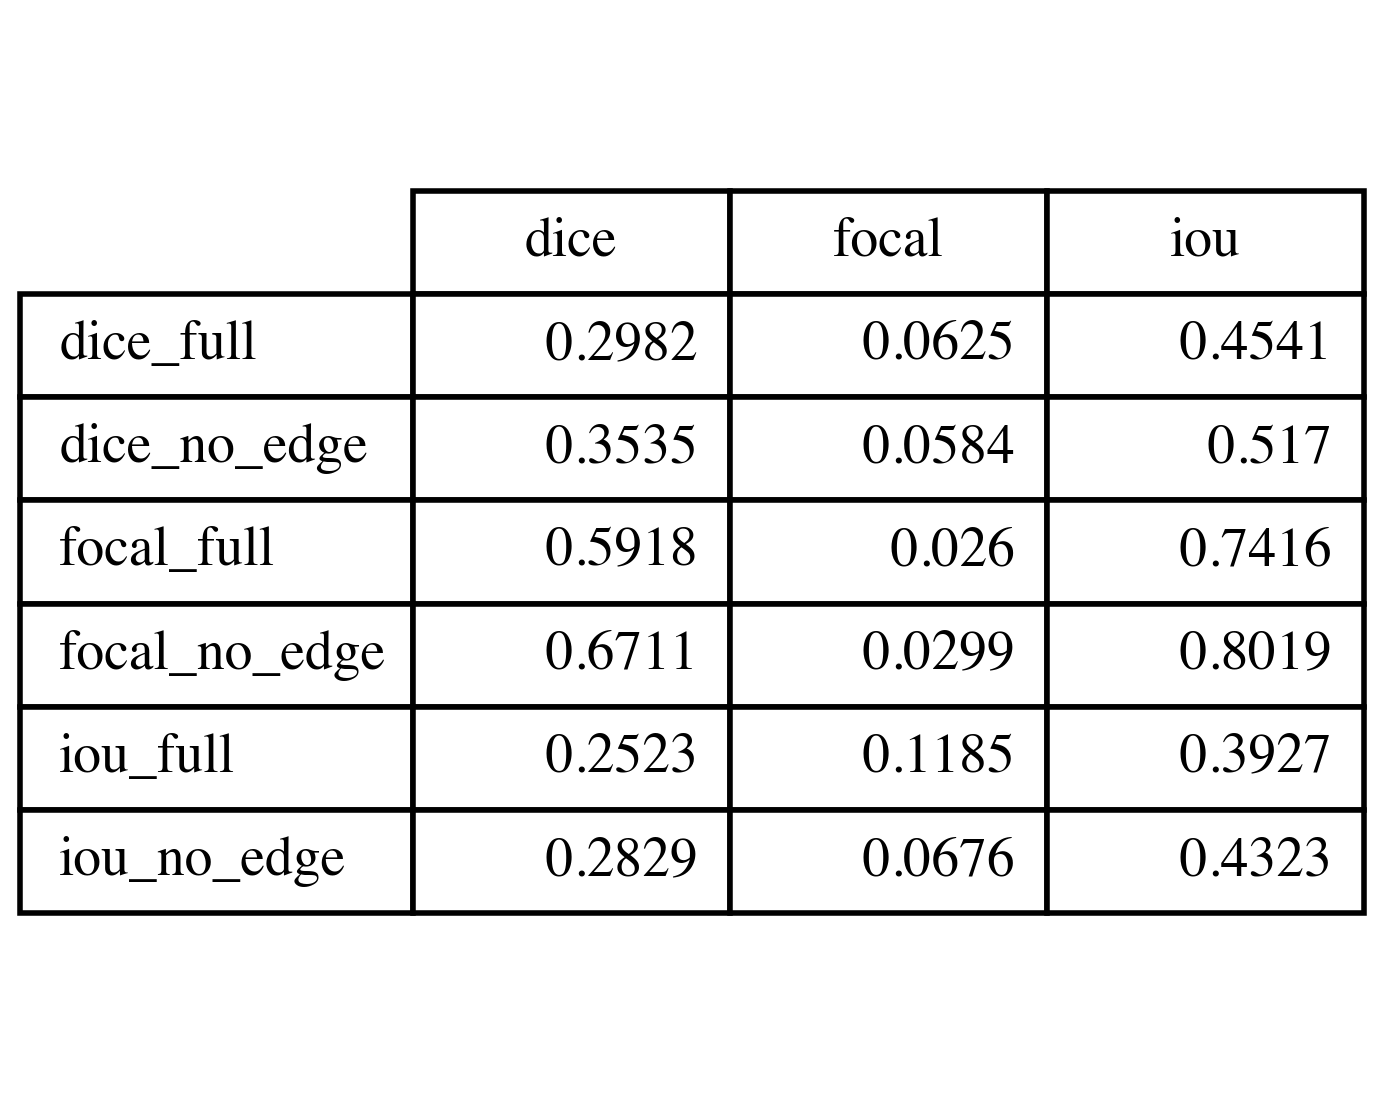

In [45]:
# Save the displayed metrics table as a PNG
df_to_save = metrics_mean_matrix.round(4)
df_to_save = df_to_save[["dice", "focal", "iou"]]

fig, ax = plt.subplots(figsize=(max(3, 1.2 * len(df_to_save.columns)), 0.5 + 0.4 * len(df_to_save)))
ax.axis("off")

tbl = ax.table(
cellText=df_to_save.values,
rowLabels=(
df_to_save.index
.str.replace(r"^configs/", "", regex=True)
.str.replace(r".toml$", "", regex=True)
),
colLabels=df_to_save.columns,
loc="center",
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.0, 1.3)

plt.tight_layout()
plt.savefig("figures/metrics_mean_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

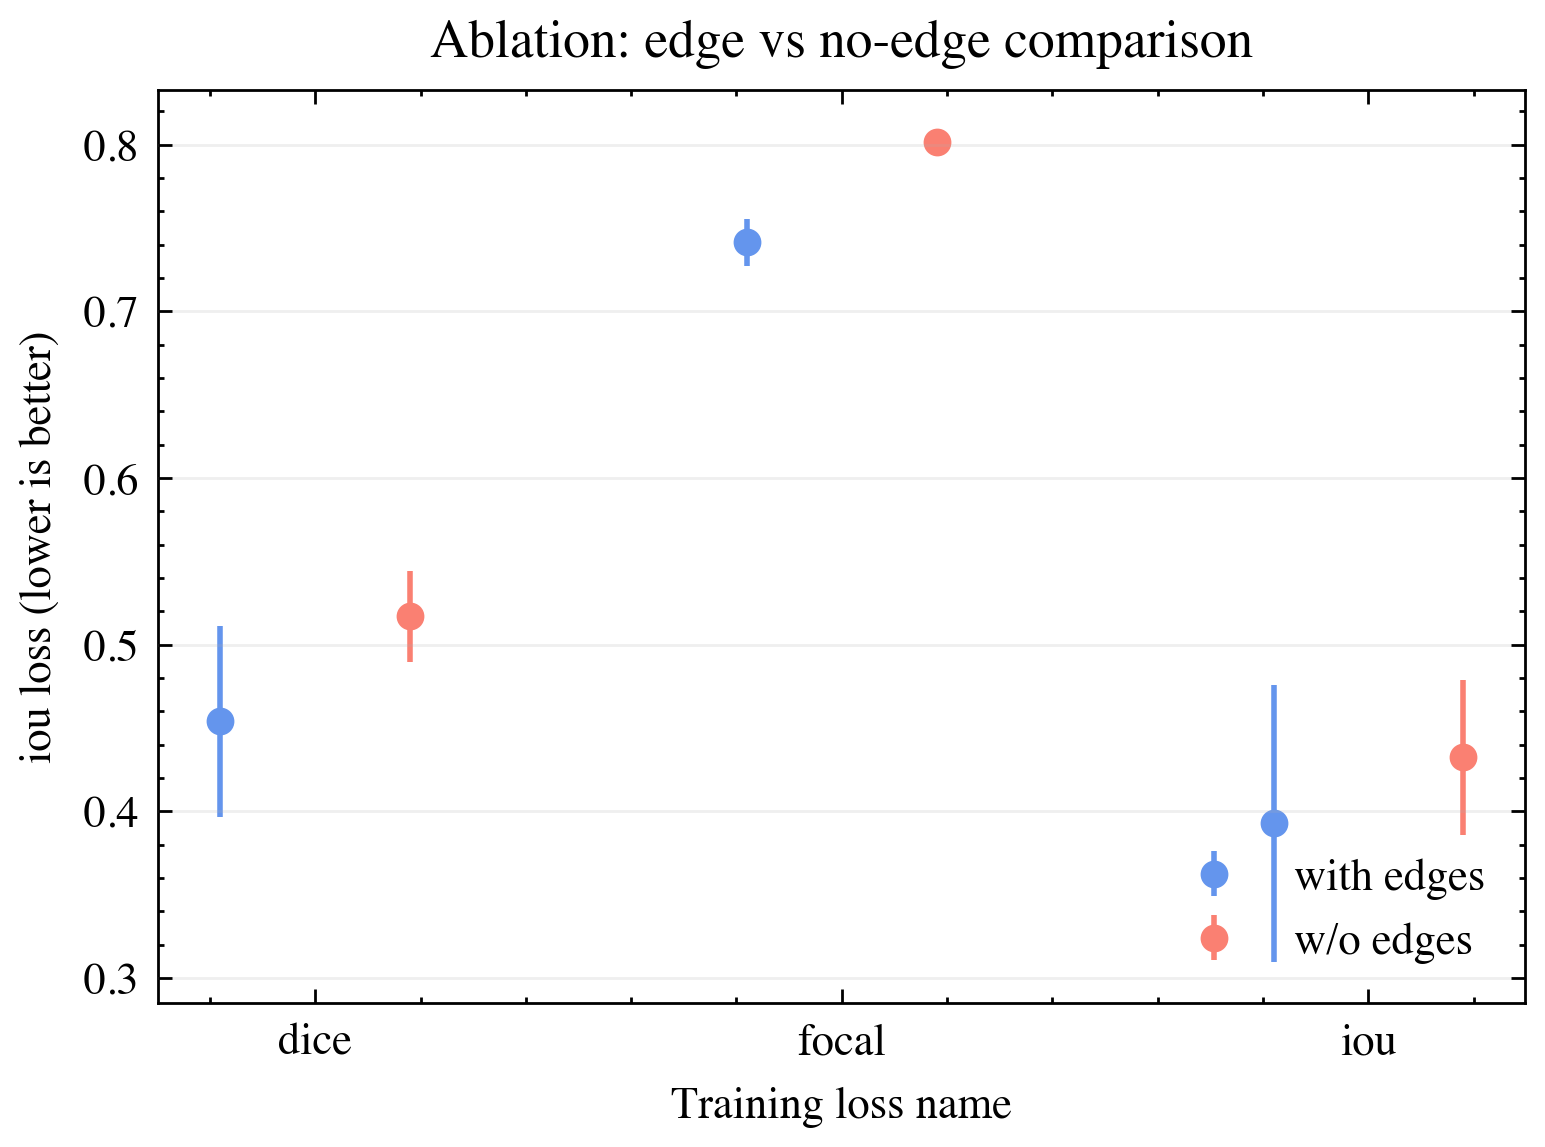

In [36]:
metric_to_plot = "iou" # "val_loss" if "val_loss" in metrics_matrix.columns else metric_cols[0]
std_col = f"{metric_to_plot}_std"

plot_rows = []
for config_name, row in metrics_matrix.iterrows():
    name = Path(config_name).stem
    variant = "no_edge" if name.endswith("_no_edge") else "edge"
    loss_name = name.replace("_no_edge", "") if variant == "no_edge" else name.replace("_full", "")

    if metric_to_plot not in row:
        continue

    mean_value = float(row[metric_to_plot])
    std_value = float(row[std_col]) if std_col in metrics_matrix.columns and pd.notna(row.get(std_col, np.nan)) else 0.0

    plot_rows.append(
        {
            "loss_name": loss_name,
            "variant": variant,
            "mean": mean_value,
            "std": std_value,
        }
    )

plot_df = pd.DataFrame(plot_rows)

# Keep only loss families where both variants are available.
if not plot_df.empty:
    counts = plot_df.groupby("loss_name")["variant"].nunique()
    valid_losses = counts[counts == 2].index.tolist()
    plot_df = plot_df[plot_df["loss_name"].isin(valid_losses)].copy()

if plot_df.empty:
    raise RuntimeError("No edge/no_edge pairs found to plot.")

loss_order = sorted(plot_df["loss_name"].unique())
x = np.arange(len(loss_order))
dx = 0.18

edge_df = plot_df[plot_df["variant"] == "edge"].set_index("loss_name").reindex(loss_order)
no_edge_df = plot_df[plot_df["variant"] == "no_edge"].set_index("loss_name").reindex(loss_order)

fig, ax = plt.subplots(figsize=(4, 3))
ax.errorbar(
    x - dx,
    edge_df["mean"].values,
    yerr=edge_df["std"].values,
    fmt="o",
    capsize=0,
    linewidth=1.0,
    markersize=4,
    color="cornflowerblue",
    label="with edges",
)
ax.errorbar(
    x + dx,
    no_edge_df["mean"].values,
    yerr=no_edge_df["std"].values,
    fmt="o",
    capsize=0,
    linewidth=1.0,
    markersize=4,
    color="salmon",
    label="w/o edges",
)

ax.set_xticks(x)
ax.set_xticklabels(loss_order)
ax.set_xlabel("Training loss name")
ax.set_ylabel(metric_to_plot + " loss (lower is better)")
ax.set_title(f"Ablation: edge vs no-edge comparison")
ax.legend(frameon=False, loc="lower right")
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig(f"figures/edge_no_edge_comparison.png", dpi=300, bbox_inches='tight')
plt.show()